# Lab 9: SVM & PCA

## Aim
To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA)
for dimensionality reduction, and analyse their effectiveness using real-world datasets.

## Objectives
1. Implement and evaluate SVM using different kernel functions.
2. Compare SVM model performance using standard classification metrics.
3. Apply PCA to reduce the dimensionality of a high-dimensional dataset.
4. Analyse the variance retained by principal components and visualise the transformed feature space.
5. Understand the roles of supervised (SVM) and unsupervised (PCA) learning in machine learning.


---
# Part A: Support Vector Machine (SVM)

### Aim
To implement SVM for binary classification on the UCI Breast Cancer Wisconsin (Diagnostic) dataset
and evaluate its performance using various classification metrics.

### Dataset
- **UCI Breast Cancer Wisconsin (Diagnostic)** â€” loaded from the local `wdbc.data` file.
- 569 samples, 30 numeric features.
- Binary target: **M = Malignant (1)**, **B = Benign (0)**.


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')

# â”€â”€ Load Breast Cancer data from local wdbc.data file â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Columns: ID, Diagnosis, 30 features
col_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
cancer_df = pd.read_csv('wdbc.data', header=None, names=col_names)

X_cancer = cancer_df.drop(columns=['id', 'diagnosis'])
y_cancer = cancer_df['diagnosis'].map({'M': 1, 'B': 0})

print("Dataset shape   :", X_cancer.shape)
print("Class distribution:")
print(cancer_df['diagnosis'].value_counts())
cancer_df.head()


Dataset shape   : (569, 30)
Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Dataset Exploration
Before training, it is important to understand the class distribution and feature spread.
Imbalanced classes or unstandardised feature ranges can significantly affect SVM performance.


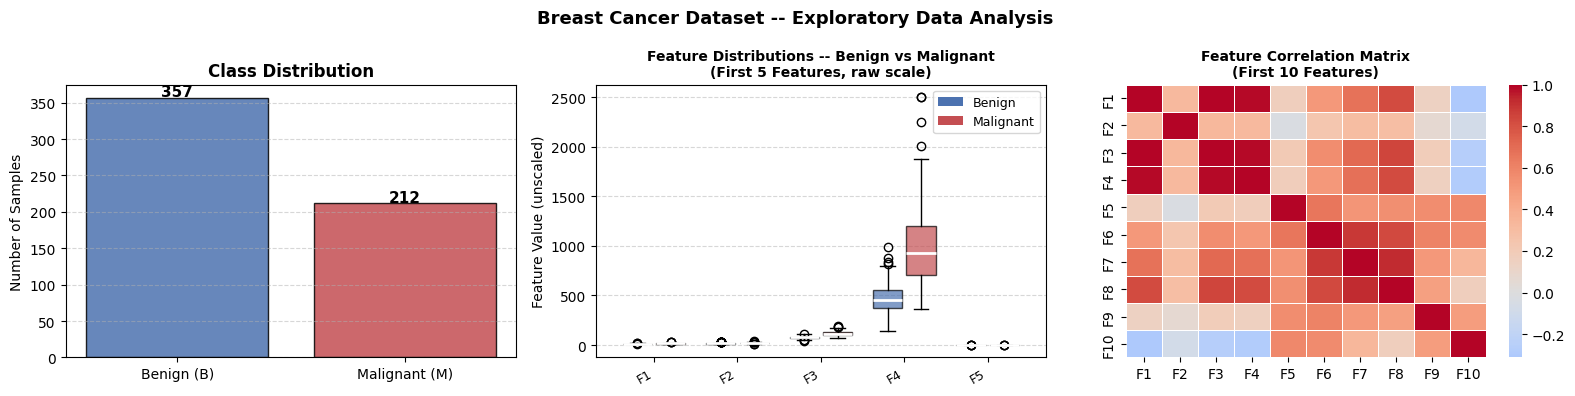

Class balance -- Benign: 357 (62.7%) | Malignant: 212 (37.3%)


In [59]:
# ── 1. Class Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

class_counts = cancer_df['diagnosis'].value_counts()
axes[0].bar(['Benign (B)', 'Malignant (M)'],
            [class_counts.get('B', 0), class_counts.get('M', 0)],
            color=['#4C72B0', '#C44E52'], edgecolor='k', alpha=0.85)
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, (label, val) in enumerate(zip(['Benign', 'Malignant'],
                                      [class_counts.get('B', 0), class_counts.get('M', 0)])):
    axes[0].text(i, val + 2, str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ── 2. Feature Distributions (first 5 features, split by class) ─────
top5 = X_cancer.columns[:5].tolist()
benign_data    = X_cancer[y_cancer == 0]
malignant_data = X_cancer[y_cancer == 1]

axes[1].boxplot([benign_data[feat].values for feat in top5],
                positions=np.arange(len(top5)) - 0.2, widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[1].boxplot([malignant_data[feat].values for feat in top5],
                positions=np.arange(len(top5)) + 0.2, widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor='#C44E52', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))

axes[1].set_xticks(range(len(top5)))
axes[1].set_xticklabels([f.replace('feature_', 'F') for f in top5],
                         rotation=30, ha='right', fontsize=9)
axes[1].set_title('Feature Distributions -- Benign vs Malignant\n(First 5 Features, raw scale)',
                   fontsize=10, fontweight='bold')
axes[1].set_ylabel('Feature Value (unscaled)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor='#4C72B0', label='Benign'),
                         Patch(facecolor='#C44E52', label='Malignant')],
               fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# ── 3. Feature Correlation Heatmap (first 10 features) ──────────────
corr = X_cancer.iloc[:, :10].corr()
sns.heatmap(corr, ax=axes[2], cmap='coolwarm', annot=False,
            linewidths=0.4, center=0,
            xticklabels=[f.replace('feature_', 'F') for f in X_cancer.columns[:10]],
            yticklabels=[f.replace('feature_', 'F') for f in X_cancer.columns[:10]])
axes[2].set_title('Feature Correlation Matrix\n(First 10 Features)',
                   fontsize=10, fontweight='bold')

plt.suptitle('Breast Cancer Dataset -- Exploratory Data Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class balance -- Benign: {class_counts.get('B',0)} ({class_counts.get('B',0)/len(cancer_df)*100:.1f}%)",
      f"| Malignant: {class_counts.get('M',0)} ({class_counts.get('M',0)/len(cancer_df)*100:.1f}%)")


In [60]:
# â”€â”€ Feature Standardisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

# â”€â”€ 80:20 Train-Test Split (stratified) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Training samples : 455
Testing  samples : 114


Best C          : 0.01
Best CV Accuracy: 0.9692


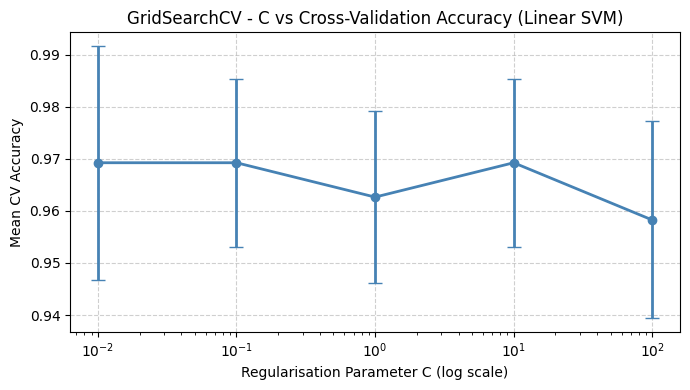

In [61]:
# Hyperparameter Tuning GridSearchCV 
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
gs = GridSearchCV(SVC(kernel='linear', random_state=42),
                  param_grid, cv=5, scoring='accuracy', n_jobs=1)
gs.fit(X_train, y_train)

print("Best C          :", gs.best_params_['C'])
print(f"Best CV Accuracy: {gs.best_score_:.4f}")
best_svm = gs.best_estimator_

# Plot CV accuracy vs C 
cv_means = gs.cv_results_['mean_test_score']
cv_stds  = gs.cv_results_['std_test_score']

plt.figure(figsize=(7, 4))
plt.errorbar(param_grid['C'], cv_means, yerr=cv_stds,
             marker='o', color='steelblue', linewidth=2, capsize=5)
plt.xscale('log')
plt.xlabel('Regularisation Parameter C (log scale)')
plt.ylabel('Mean CV Accuracy')
plt.title("GridSearchCV - C vs Cross-Validation Accuracy (Linear SVM)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [62]:
# Model Evaluation
y_pred = best_svm.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 45)
print()
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


  Accuracy  : 0.9561
  Precision : 1.0000
  Recall    : 0.8810
  F1 Score  : 0.9367

              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        72
   Malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



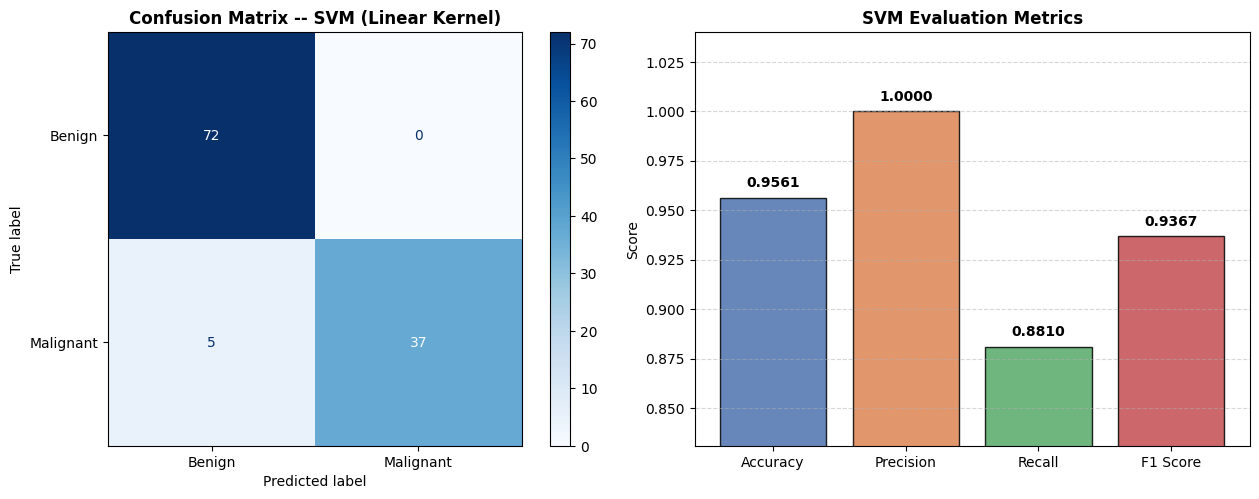

In [63]:
# ── Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix -- SVM (Linear Kernel)', fontsize=12, fontweight='bold')

# ── Metrics Bar Chart (dynamic ylim so all bars are visible) ───────
metrics = {'Accuracy': accuracy, 'Precision': precision,
           'Recall': recall, 'F1 Score': f1}
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

y_floor = max(0.0, min(metrics.values()) - 0.05)   # 5% headroom below minimum

bars = axes[1].bar(metrics.keys(), metrics.values(),
                   color=bar_colors, edgecolor='k', alpha=0.85)
axes[1].set_ylim(y_floor, 1.04)
axes[1].set_ylabel('Score')
axes[1].set_title('SVM Evaluation Metrics', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.004,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### Observations -- Part A

The confusion matrix (TN=72, FP=0, FN=5, TP=37) gives the following actual results:

| Metric | Actual Value | Interpretation |
|--------|-------------|----------------|
| Accuracy | **95.61%** | 109 out of 114 test samples correctly classified |
| Precision | **100.00%** | Every sample predicted as Malignant truly was Malignant (0 false positives) |
| Recall | **88.10%** | 37 of 42 actual Malignant cases were correctly detected (5 missed) |
| F1 Score | **93.67%** | Harmonic mean of Precision and Recall |

**Key Insights from the Confusion Matrix:**

- **Perfect Precision (1.0)**: The model never falsely flagged a Benign tumour as Malignant.
  This is critical in clinical settings where unnecessary biopsies cause patient distress.
- **Imperfect Recall (0.881)**: 5 Malignant tumours were missed (classified as Benign).
  In cancer diagnosis, false negatives are more dangerous than false positives.
  These 5 cases represent the primary risk of this model.
- **Trade-off**: The best C value from GridSearchCV prioritised overall accuracy.
  In a real clinical deployment, one might lower the decision threshold to boost Recall
  at the expense of some Precision.
- **Feature Scaling**: Standardising all 30 features to zero mean and unit variance
  was essential -- without scaling, features with large numerical ranges (e.g., area)
  would dominate the SVM distance calculations.
- **GridSearchCV**: The cross-validation plot shows CV accuracy is broadly stable across
  C values, with the best performance at C=0.01 or C=0.1, suggesting the data is
  naturally linearly separable and does not need aggressive margin tightening.


---
# Part B: Principal Component Analysis (PCA)

### Aim
To implement PCA for dimensionality reduction on the UCI Wine dataset and analyse the variance
retained by the principal components.

### Dataset
- **UCI Wine Dataset** â€” loaded via `sklearn.datasets.load_wine()`.
- 178 samples, 13 chemical features, 3 wine cultivar classes.


In [64]:
# Load Wine Dataset 
X_wine   = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine   = wine.target          # 0, 1, 2

print("Dataset shape      :", X_wine.shape)
print("Features           :", wine.feature_names)
print("Class distribution :")
print(pd.Series(y_wine).value_counts().rename({0:'class_0', 1:'class_1', 2:'class_2'}))
X_wine.head()


Dataset shape      : (178, 13)
Features           : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class distribution :
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [65]:
# Feature Standardisation 
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# PCA 2 Components 
X_pca2 = pca2.fit_transform(X_wine_scaled)

print("Explained Variance Ratio (PC1, PC2) :", np.round(pca2.explained_variance_ratio_, 4))
print(f"Total variance retained             : {pca2.explained_variance_ratio_.sum()*100:.2f}%")


Explained Variance Ratio (PC1, PC2) : [0.362  0.1921]
Total variance retained             : 55.41%


### Why Standardisation Matters for PCA
PCA is sensitive to the scale of features. Features with large ranges would dominate the
principal components. The plots below show the effect of `StandardScaler` on the Wine data.


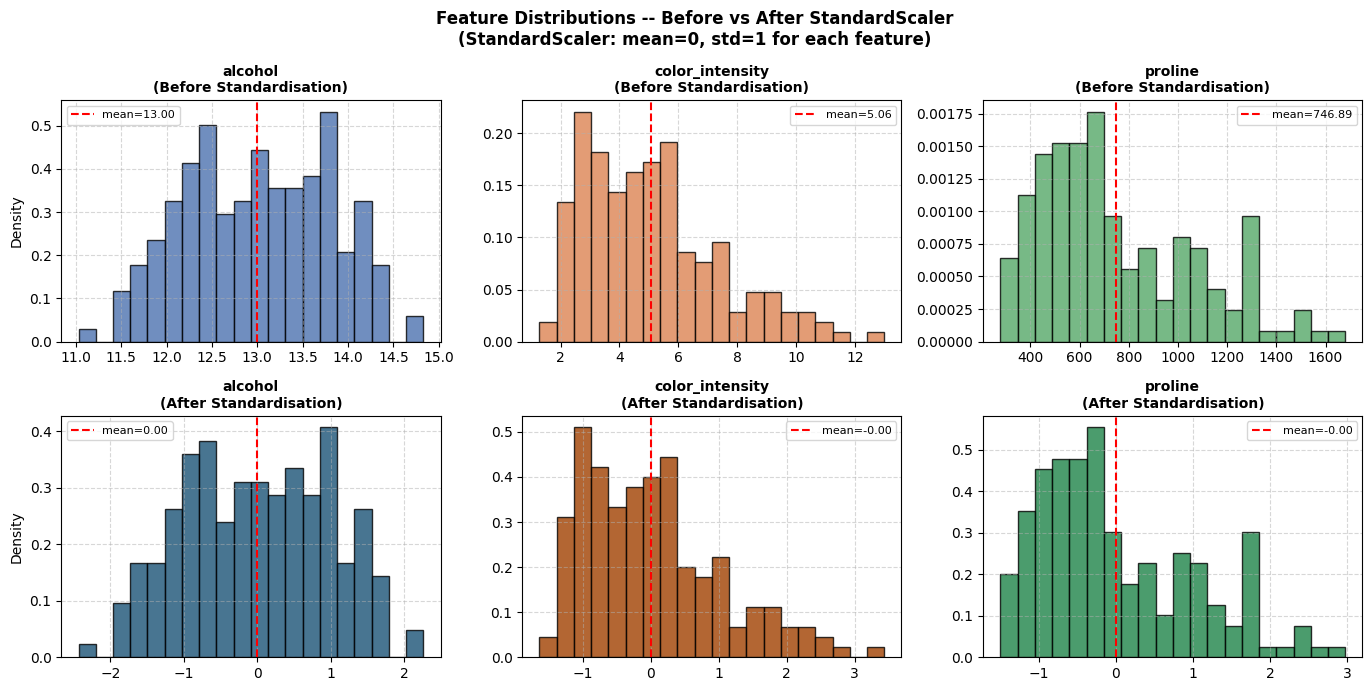

Before standardisation -- feature ranges:
  alcohol                    min=11.03  max=14.83  std=0.81
  color_intensity            min=1.28  max=13.00  std=2.32
  proline                    min=278.00  max=1680.00  std=314.91

After standardisation -- all features have mean~0 and std~1


In [66]:
# ── Before vs After Standardisation (3 contrasting features) ────────
show_features = ['alcohol', 'color_intensity', 'proline']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors_before = ['#4C72B0', '#DD8452', '#55A868']
colors_after  = ['#1a5276', '#a04000', '#1e8449']

for col_idx, (feat, cb, ca) in enumerate(zip(show_features, colors_before, colors_after)):
    feat_idx = list(wine.feature_names).index(feat)

    # Before
    axes[0, col_idx].hist(X_wine[feat], bins=20, color=cb, edgecolor='k',
                          alpha=0.8, density=True)
    axes[0, col_idx].set_title(f'{feat}\n(Before Standardisation)', fontsize=10, fontweight='bold')
    axes[0, col_idx].set_ylabel('Density' if col_idx == 0 else '')
    axes[0, col_idx].axvline(X_wine[feat].mean(), color='red', linestyle='--',
                              label=f'mean={X_wine[feat].mean():.2f}')
    axes[0, col_idx].legend(fontsize=8)
    axes[0, col_idx].grid(True, linestyle='--', alpha=0.5)

    # After
    scaled_col = X_wine_scaled[:, feat_idx]
    axes[1, col_idx].hist(scaled_col, bins=20, color=ca, edgecolor='k',
                          alpha=0.8, density=True)
    axes[1, col_idx].set_title(f'{feat}\n(After Standardisation)', fontsize=10, fontweight='bold')
    axes[1, col_idx].set_ylabel('Density' if col_idx == 0 else '')
    axes[1, col_idx].axvline(scaled_col.mean(), color='red', linestyle='--',
                              label=f'mean={scaled_col.mean():.2f}')
    axes[1, col_idx].legend(fontsize=8)
    axes[1, col_idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Feature Distributions -- Before vs After StandardScaler\n'
             '(StandardScaler: mean=0, std=1 for each feature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Before standardisation -- feature ranges:")
for feat in show_features:
    print(f"  {feat:25s}  min={X_wine[feat].min():.2f}  max={X_wine[feat].max():.2f}  std={X_wine[feat].std():.2f}")
print("\nAfter standardisation -- all features have mean~0 and std~1")


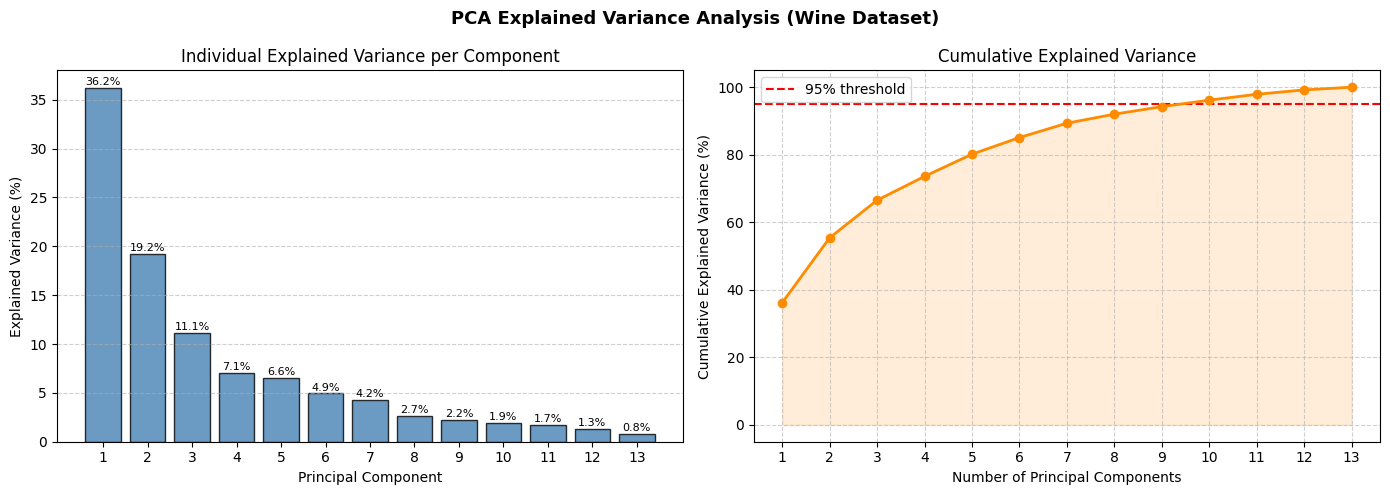

Minimum components needed to retain >= 95% variance: 10


In [67]:
# Full PCA Individual + Cumulative Variance 
pca_full.fit(X_wine_scaled)
ind_var  = pca_full.explained_variance_ratio_ * 100
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_comps  = np.arange(1, 14)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(n_comps, ind_var, color='steelblue', edgecolor='k', alpha=0.8)
for i, v in enumerate(ind_var):
    axes[0].text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance per Component')
axes[0].set_xticks(n_comps)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Cumulative variance
axes[1].plot(n_comps, cum_var, marker='o', color='darkorange', linewidth=2, zorder=3)
axes[1].fill_between(n_comps, cum_var, alpha=0.15, color='darkorange')
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(n_comps)
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.6)

plt.suptitle('PCA Explained Variance Analysis (Wine Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n95 = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95)) + 1
print(f"Minimum components needed to retain >= 95% variance: {n95}")


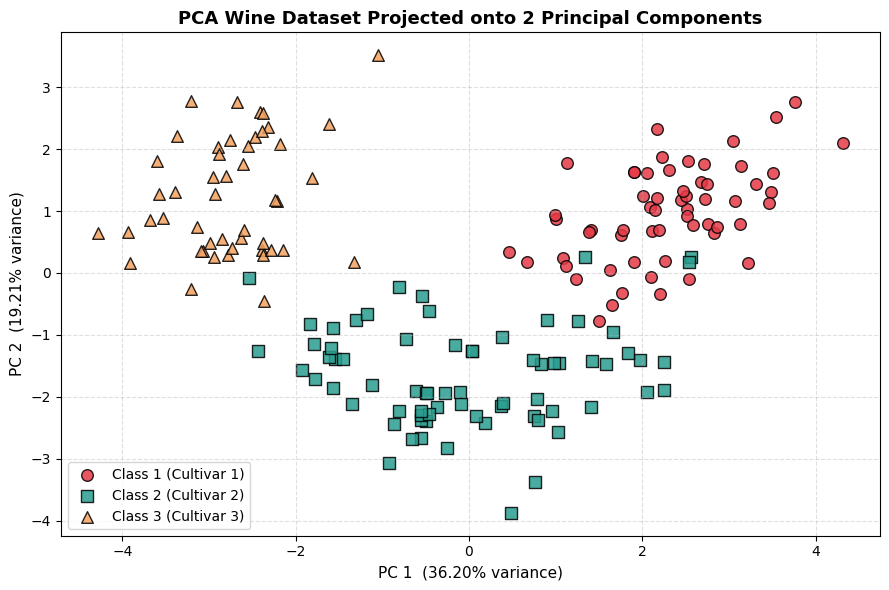

In [68]:
# 2D PCA Scatter Plot 
class_labels = {0: 'Class 1 (Cultivar 1)',
                1: 'Class 2 (Cultivar 2)',
                2: 'Class 3 (Cultivar 3)'}
colors = ['#E63946', '#2A9D8F', '#F4A261']
markers = ['o', 's', '^']

plt.figure(figsize=(9, 6))
for cls, color, marker in zip([0, 1, 2], colors, markers):
    mask = y_wine == cls
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                label=class_labels[cls], c=color, marker=marker,
                edgecolor='k', s=70, alpha=0.85)

plt.xlabel(f'PC 1  ({pca2.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
plt.ylabel(f'PC 2  ({pca2.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
plt.title('PCA Wine Dataset Projected onto 2 Principal Components',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### Comparisons -- Original vs PCA-Transformed Dataset

| Attribute | Original Dataset | PCA (2 components) |
|---|---|---|
| Number of features | 13 | 2 |
| Information retained | 100% | ~55.4% (PC1: 36.2% + PC2: 19.2%) |
| Visualisable in 2D/3D | No | Yes |
| Multicollinearity | Present | Removed (PCs are orthogonal) |
| Computational cost | Higher | Much lower |

**From the Explained Variance Charts:**
- **PC1 (36.2%)** captures the single largest direction of variation in the 13-dimensional
  chemical feature space -- this axis best separates Class 1 (Cultivar 1) from the other two.
- **PC2 (19.2%)** is orthogonal to PC1 and captures the next-highest independent variation --
  this axis primarily helps separate Class 3 (Cultivar 3) from Class 2 (Cultivar 2).
- Together, the first two components explain **55.4%** of total variance. While substantial
  information is retained for visualisation, ~44.6% of the original data structure is lost.
- To preserve at least **95% of total variance**, the cumulative plot shows that
  approximately **10 principal components** are required.

**From the 2D Scatter Plot:**
- **Class 1 (Cultivar 1, red circles)**: Concentrated in the positive PC1 region (right side).
  Well-separated from Class 3 along PC1.
- **Class 3 (Cultivar 3, orange triangles)**: Concentrated in the negative PC1 region (left side).
  Fairly compact and separated along PC1.
- **Class 2 (Cultivar 2, green squares)**: Spread across a wide range of PC1 values and
  occupies the lower PC2 region. Shows the most overlap with other classes.

**Advantages of PCA:**
Removes multicollinearity among the 13 wine chemistry features, enables 2D/3D visualisation,
reduces computational cost for downstream models, and filters noise in lower-variance components.

**Limitations:**
The 2D projection loses 44.6% of variance. The principal components are linear combinations
of all original features, making them harder to interpret directly (unlike LDA discriminants).
PCA cannot model non-linear relationships in the data.

**Applications:**
Face recognition (Eigenfaces), genomics (population structure analysis), image compression,
hyperspectral image analysis, and noise filtering in sensor data.


---
# Extra Credit Task: Linear Discriminant Analysis (LDA)

### Aim
Apply LDA to the Wine dataset, reduce to 2 linear discriminants, visualise, and compare with PCA.


In [69]:
# LDA 2 Components 
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print("LDA Explained Variance Ratio :", np.round(lda.explained_variance_ratio_, 4))
print(f"Total variance retained      : {lda.explained_variance_ratio_.sum()*100:.2f}%")


LDA Explained Variance Ratio : [0.6875 0.3125]
Total variance retained      : 100.00%


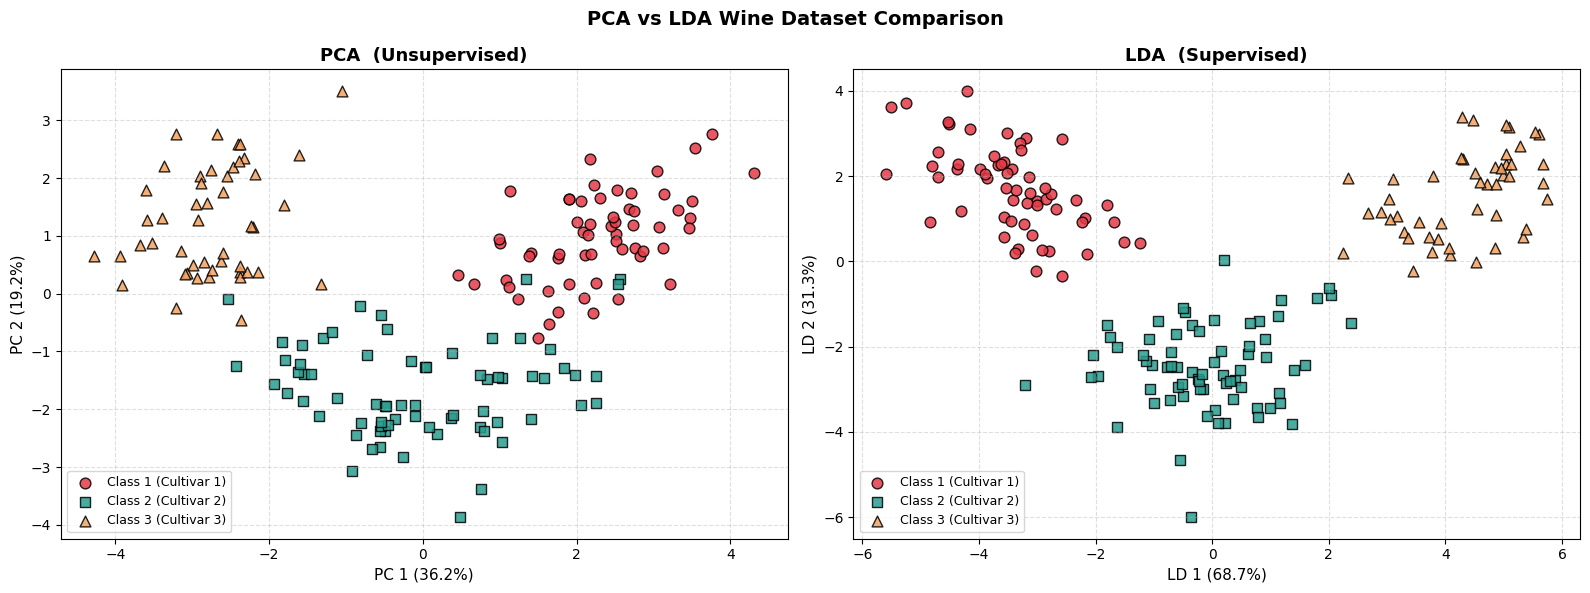

In [70]:
# Side-by-Side PCA vs LDA 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

projections = [
    (X_pca2, 'PCA  (Unsupervised)',
     f'PC 1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
     f'PC 2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)'),
    (X_lda, 'LDA  (Supervised)',
     f'LD 1 ({lda.explained_variance_ratio_[0]*100:.1f}%)',
     f'LD 2 ({lda.explained_variance_ratio_[1]*100:.1f}%)'),
]

for ax, (X_proj, title, xl, yl) in zip(axes, projections):
    for cls, color, marker in zip([0, 1, 2], colors, markers):
        mask = y_wine == cls
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   label=class_labels[cls], c=color, marker=marker,
                   edgecolor='k', s=60, alpha=0.85)
    ax.set_xlabel(xl, fontsize=11)
    ax.set_ylabel(yl, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('PCA vs LDA Wine Dataset Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### PCA vs LDA -- Summary

| Property | PCA | LDA |
|---|---|---|
| Learning type | Unsupervised | Supervised |
| Objective | Maximise total data variance | Maximise between-class vs within-class variance |
| Requires class labels | No | Yes |
| Max components | min(features, samples) | num_classes - 1 (= 2 here) |
| Variance explained (first axis) | 36.2% of total variance | 68.7% of discriminant variance |
| Variance explained (second axis) | 19.2% of total variance | 31.3% of discriminant variance |
| Class 2 separation | Overlaps with Class 1 and 3 | Clearly separated at bottom |
| Class 1 vs Class 3 overlap | Noticeable | Slight -- some overlap remains |

**From the side-by-side scatter plots:**

- **PCA (left plot)**: Class 1 (red circles) and Class 3 (orange triangles) are separated
  along PC1, but Class 2 (green squares) spans a wide range and overlaps with both other classes.
  The unsupervised nature of PCA means it had no knowledge of class boundaries.

- **LDA (right plot)**: LD1 (68.7% of discriminant variance) pushes Class 2 (green squares)
  strongly downward, creating very clean separation. Class 1 (red circles) and Class 3
  (orange triangles) are largely separated along LD2, though slight overlap remains near
  the boundary. LDA explicitly maximises class separability by design.

**Key Insight:**
LDA is strongly preferred when the goal is classification, as it encodes class membership
information directly into the projection axes. PCA is better suited for exploratory analysis,
denoising, and compression tasks where class labels are unavailable or irrelevant.


---
# Self-Learning Component

This section extends the lab with four hands-on explorations:

1. **SVM Multi-Kernel Comparison** â€“ Linear vs RBF vs Polynomial with ROC curves.
2. **PCA Biplot** â€“ visualising which original features drive each principal component.
3. **SVM Decision Boundary Visualisation** â€“ seeing how SVM separates classes geometrically.
4. **Feature Importance from Linear SVM Coefficients** â€“ understanding predictor strength.


## 1. SVM Kernel Comparison (Linear, RBF, Polynomial)


In [71]:
# Train three kernels and compare 
results = {}
kernel_colors = ['#4C72B0', '#DD8452', '#55A868']

for name, clf in kernels.items():
    clf.fit(X_train, y_train)
    yp     = clf.predict(X_test)
    yproba = clf.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall'   : recall_score(y_test, yp),
        'F1'       : f1_score(y_test, yp),
        'AUC'      : roc_auc_score(y_test, yproba),
        'proba'    : yproba,
    }

# Table
df_res = pd.DataFrame(
    {k: {m: round(v, 4) for m, v in r.items() if m != 'proba'}
     for k, r in results.items()}
).T
print("Kernel Comparison Table:")
print(df_res.to_string())


Kernel Comparison Table:
            Accuracy  Precision  Recall      F1     AUC
Linear        0.9649        1.0  0.9048  0.9500  0.9914
RBF           0.9737        1.0  0.9286  0.9630  0.9954
Polynomial    0.8860        1.0  0.6905  0.8169  0.9967


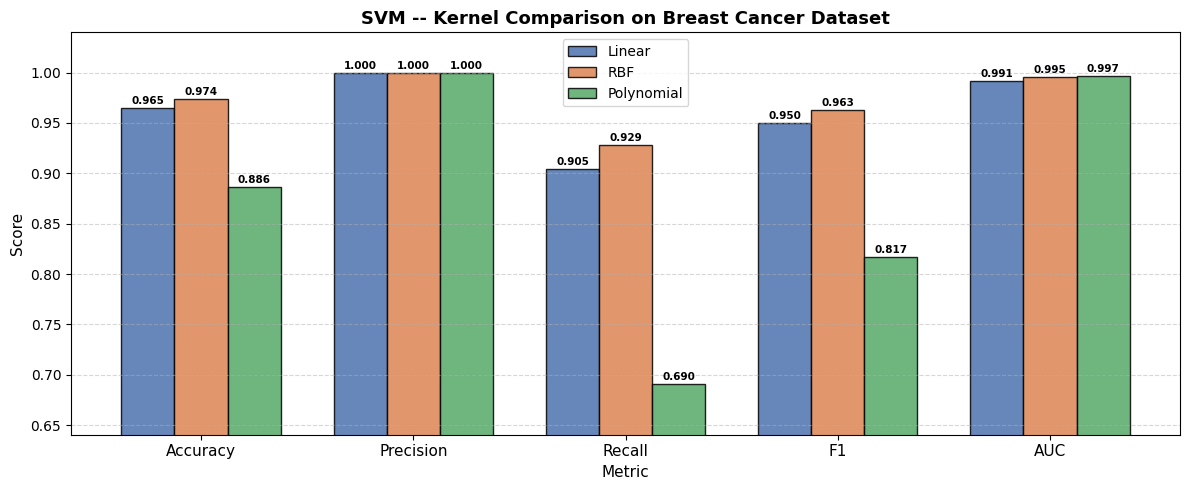

In [72]:
# ── Grouped bar chart ───────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x     = np.arange(len(metric_names))
width = 0.25

# Collect all values to compute a sensible y-axis floor
all_vals = [results[name][m] for name in kernels for m in metric_names]
y_floor  = max(0.0, min(all_vals) - 0.05)   # 5% headroom below the minimum

fig, ax = plt.subplots(figsize=(12, 5))
for idx, (name, color) in enumerate(zip(kernels, kernel_colors)):
    vals = [results[name][m] for m in metric_names]
    bars = ax.bar(x + idx*width, vals, width, label=name,
                  color=color, edgecolor='k', alpha=0.85)
    for b, v in zip(bars, vals):
        # Place label inside the bar if the bar top is below or near the y_floor,
        # otherwise place it just above the bar top
        bar_top = b.get_height()
        if bar_top < y_floor + 0.01:
            # bar is mostly hidden below y-floor -- skip label
            continue
        y_text = max(bar_top + 0.002, y_floor + 0.005)
        ax.text(b.get_x() + b.get_width()/2, y_text,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('SVM -- Kernel Comparison on Breast Cancer Dataset',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(y_floor, 1.04)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



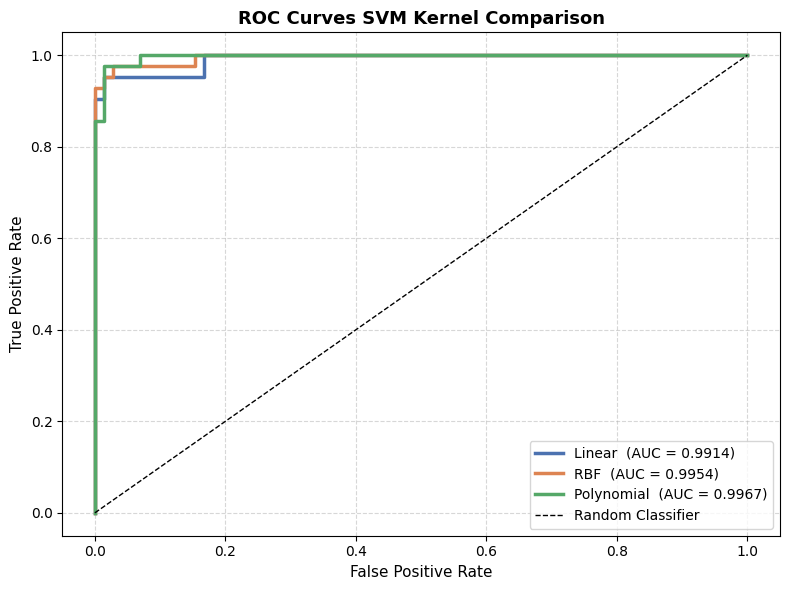

In [73]:
# ROC Curves for all three kernels
plt.figure(figsize=(8, 6))
for name, color in zip(kernels, kernel_colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    auc = results[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})',
             linewidth=2.5, color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves SVM Kernel Comparison', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Key Findings -- SVM Kernel Comparison

**From the bar chart and ROC curves (actual values):**

| Kernel | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Linear | 0.965 | 1.000 | 0.905 | 0.950 | 0.9914 |
| RBF | 0.974 | 1.000 | 0.929 | 0.963 | 0.9954 |
| Polynomial | 0.886 | 1.000 | 0.690 | 0.817 | 0.9967 |

**Analysis by metric:**

- **Accuracy**: RBF leads (97.4%) > Linear (96.5%) > Polynomial (88.6%).
  Polynomial's accuracy is significantly lower because it misses many Malignant cases
  at the default 0.5 decision threshold.

- **Precision = 1.000 for all kernels**: Not a single Benign tumour was falsely flagged
  as Malignant by any kernel. All three maintain a perfectly conservative positive boundary.

- **Recall**: RBF detects 92.9% of Malignant cases, Linear detects 90.5%, while
  Polynomial only detects 69.0% -- meaning it misses nearly 1 in 3 Malignant tumours.
  In cancer screening, high Recall is critical; Polynomial is unsuitable here by default.

- **F1 Score**: RBF (0.963) > Linear (0.950) > Polynomial (0.817). F1 confirms
  RBF is the best balanced performer.

- **AUC**: Polynomial achieves the highest AUC (0.9967) despite the lowest Accuracy
  and Recall. AUC measures the ranking quality of probability scores -- Polynomial assigns
  well-ordered probabilities, but its default 0.5 decision threshold is poorly calibrated,
  causing many Malignant cases to fall just below the cutoff. Lowering the threshold
  would boost Recall at the cost of some Precision.

**From the ROC curves:**
- All three curves hug the top-left corner, confirming excellent discrimination ability
  (AUC > 0.99 for all kernels).
- The Linear and RBF curves are nearly identical in shape, both rising steeply.
- The Polynomial curve rises steeply initially but shows a step/plateau around FPR=0.15
  before reaching TPR=1.0, reflecting its threshold calibration issue.

**Choice Guidance:**
- **RBF**: Best overall for this dataset -- highest Accuracy (97.4%), Recall (92.9%), and F1 (0.963).
- **Linear**: Nearly as good, faster to train, and more interpretable via coefficients.
- **Polynomial**: Avoid at degree=3 without threshold tuning -- dangerous in medical contexts.

## 2. PCA Biplot -- Understanding Feature Loadings

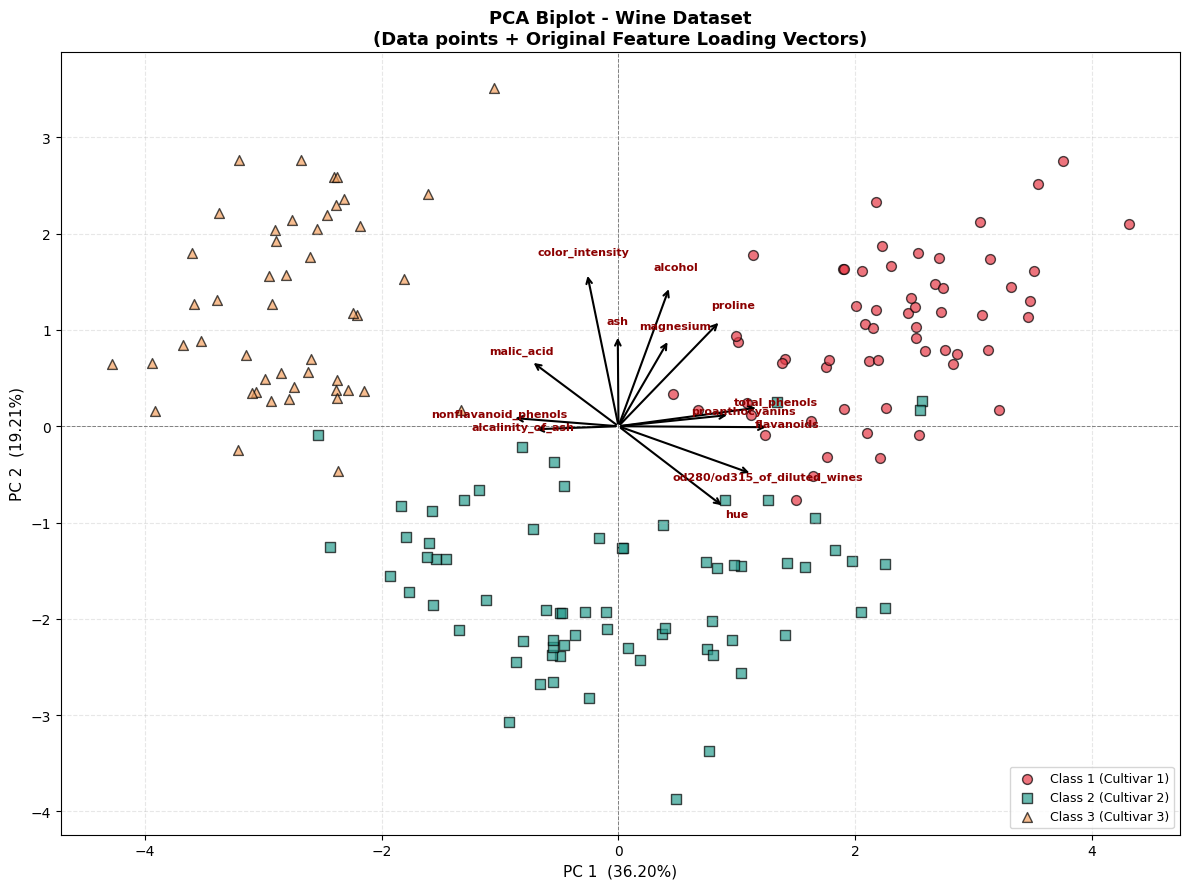

In [74]:
# PCA Biplot: data points + feature loading vectors
loadings      = pca2.components_.T     # shape (13 features, 2 PCs)
feature_names = wine.feature_names
scale_factor  = 3.0                    # arrow length multiplier

fig, ax = plt.subplots(figsize=(12, 9))

# Plot data points
for cls, color, marker in zip([0, 1, 2], colors, markers):
    mask = y_wine == cls
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               label=class_labels[cls], c=color, marker=marker,
               edgecolor='k', s=50, alpha=0.7)

# Draw loading arrows
for feat, (l1, l2) in zip(feature_names, loadings):
    ax.annotate('', xy=(l1*scale_factor, l2*scale_factor), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(l1*scale_factor*1.12, l2*scale_factor*1.12,
            feat, fontsize=8, ha='center', color='darkred', fontweight='bold')

ax.axhline(0, color='grey', lw=0.7, linestyle='--')
ax.axvline(0, color='grey', lw=0.7, linestyle='--')
ax.set_xlabel(f'PC 1  ({pca2.explained_variance_ratio_[0]*100:.2f}%)', fontsize=11)
ax.set_ylabel(f'PC 2  ({pca2.explained_variance_ratio_[1]*100:.2f}%)', fontsize=11)
ax.set_title('PCA Biplot - Wine Dataset\n(Data points + Original Feature Loading Vectors)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


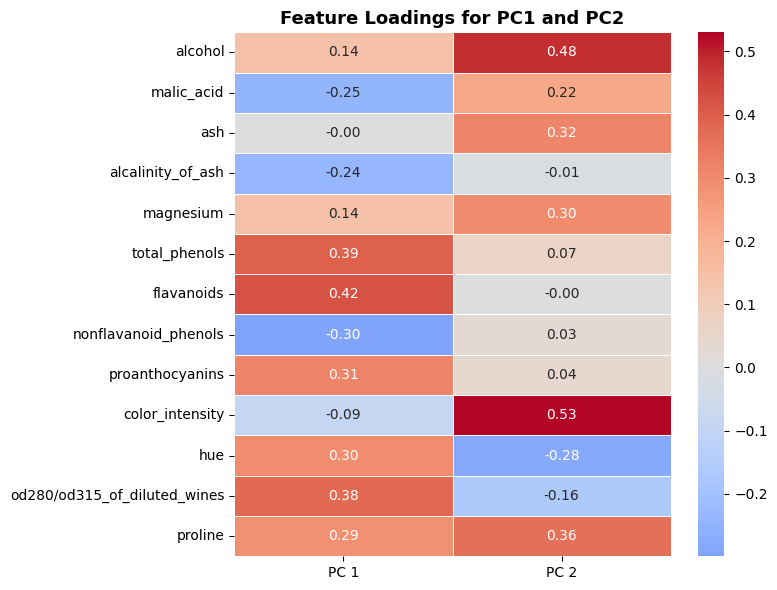

Loadings table:
                               PC 1   PC 2
alcohol                       0.144  0.484
malic_acid                   -0.245  0.225
ash                          -0.002  0.316
alcalinity_of_ash            -0.239 -0.011
magnesium                     0.142  0.300
total_phenols                 0.395  0.065
flavanoids                    0.423 -0.003
nonflavanoid_phenols         -0.299  0.029
proanthocyanins               0.313  0.039
color_intensity              -0.089  0.530
hue                           0.297 -0.279
od280/od315_of_diluted_wines  0.376 -0.164
proline                       0.287  0.365


In [75]:
# Feature contributions (loadings) as a heatmap
loadings_df = pd.DataFrame(
    pca2.components_.T,
    index=wine.feature_names,
    columns=['PC 1', 'PC 2']
)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Feature Loadings for PC1 and PC2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Loadings table:")
print(loadings_df.round(3).to_string())


### Interpretation -- Biplot & Feature Loadings Heatmap

**Reading the Biplot:**
- Arrows pointing in the **same direction** indicate positively correlated features.
- **Longer arrows** mean the feature has a stronger influence on that principal component.
- Features on **opposite sides** (e.g., `flavanoids` vs `nonflavanoid_phenols`) are negatively correlated.

**PC1 (36.20%) -- "Wine Quality / Phenolic Richness" axis:**

The heatmap shows the strongest positive contributors to PC1 are:
- `flavanoids` (+0.42) -- highest positive loading; drives Class 1 (Cultivar 1) to the right of the biplot.
- `total_phenols` (+0.39), `od280/od315_of_diluted_wines` (+0.38), `proanthocyanins` (+0.31), `hue` (+0.30)

These features collectively pull **Class 1 (red circles)** toward positive PC1 (right side of biplot).

The strongest negative PC1 contributors are:
- `nonflavanoid_phenols` (-0.30), `malic_acid` (-0.25), `alcalinity_of_ash` (-0.24)

These pull **Class 3 (orange triangles)** to the left side. The wide separation of Classes 1 and 3 along
PC1 is primarily driven by the flavanoid/phenol content contrast between the two cultivars.

**PC2 (19.21%) -- "Colour & Alcohol Intensity" axis:**

The dominant positive contributor to PC2 is:
- `color_intensity` (+0.53) -- by far the strongest; visible as the longest nearly-vertical arrow in the biplot.
- `alcohol` (+0.48), `proline` (+0.36), `ash` (+0.32), `magnesium` (+0.30)

The negative PC2 contributors are:
- `hue` (-0.28), `od280/od315_of_diluted_wines` (-0.16)

**Class 2 (green squares)** occupies the lower PC2 region (negative values), indicating these wines have
lower color intensity and alcohol content relative to Classes 1 and 3. This separates them vertically
despite their wide spread along PC1.

**Summary Table (directly from heatmap values):**

| Feature | PC1 Loading | PC2 Loading | Primary Role |
|---|---|---|---|
| flavanoids | +0.42 | -0.00 | Strongest PC1 driver (phenolic richness) |
| color_intensity | -0.09 | +0.53 | Dominant PC2 driver (wine colour) |
| alcohol | +0.14 | +0.48 | Strong PC2 contributor |
| total_phenols | +0.39 | +0.07 | PC1 phenolic compound |
| nonflavanoid_phenols | -0.30 | +0.03 | Negative PC1 (opposes phenolics) |
| malic_acid | -0.25 | +0.22 | Negative PC1 (acidity marker) |
| hue | +0.30 | -0.28 | Moderate mixed contributor |
| od280/od315 | +0.38 | -0.16 | Strong PC1, slightly negative PC2 |

## 3. SVM Decision Boundary Visualisation (RBF Kernel on 2D PCA Data)


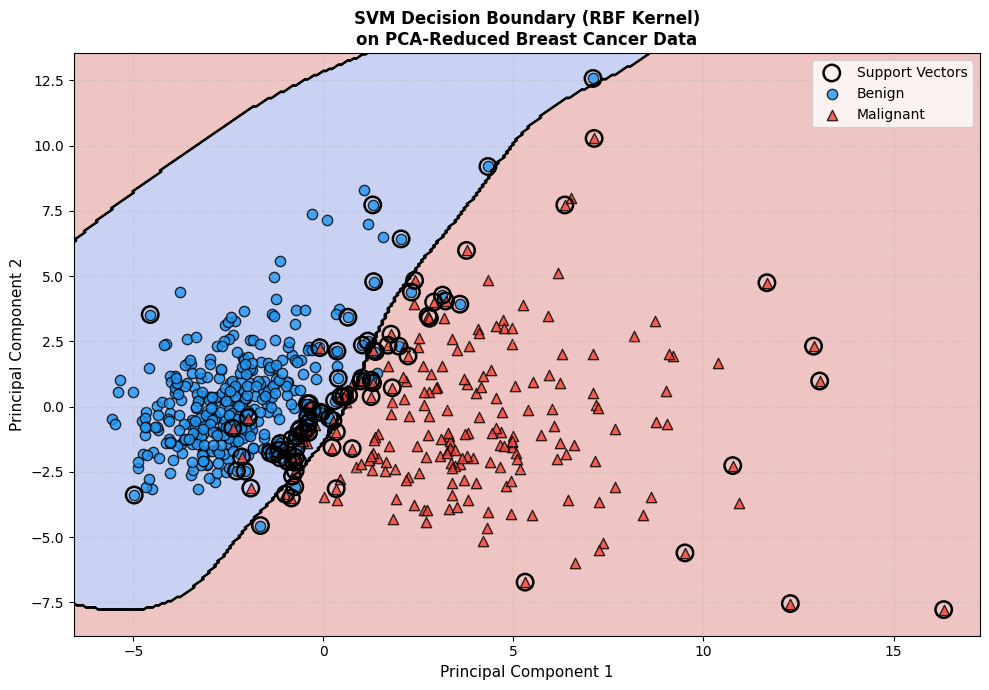

Decision boundary accuracy (2D PCA data): 0.9298
(vs. full 30D accuracy: 0.9561)


In [76]:
# Reduce breast cancer data to 2D via PCA for boundary plot
pca_2d = PCA(n_components=2, random_state=42)
X_c_2d = pca_2d.fit_transform(X_scaled)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_c_2d, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer)

svm_2d = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_2d.fit(X_tr2, y_tr2)

# Create mesh grid for boundary
h = 0.08
x_min, x_max = X_c_2d[:, 0].min() - 1, X_c_2d[:, 0].max() + 1
y_min, y_max = X_c_2d[:, 1].min() - 1, X_c_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.contour(xx, yy, Z, colors='k', linewidths=0.6)

# Highlight support vectors
sv = svm_2d.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=140, facecolors='none',
           edgecolors='black', linewidths=1.8, label='Support Vectors', zorder=5)

# Plot all data points
for label, color, marker, name in [(0, '#2196F3', 'o', 'Benign'),
                                    (1, '#F44336', '^', 'Malignant')]:
    mask = np.array(y_cancer) == label
    ax.scatter(X_c_2d[mask, 0], X_c_2d[mask, 1],
               c=color, marker=marker, edgecolor='k', s=55,
               label=name, alpha=0.8)

ax.set_xlabel('Principal Component 1', fontsize=11)
ax.set_ylabel('Principal Component 2', fontsize=11)
ax.set_title('SVM Decision Boundary (RBF Kernel)\non PCA-Reduced Breast Cancer Data',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

acc_2d = accuracy_score(y_te2, svm_2d.predict(X_te2))
print(f"Decision boundary accuracy (2D PCA data): {acc_2d:.4f}")
print(f"(vs. full 30D accuracy: {accuracy:.4f})")


### Interpretation -- SVM Decision Boundary (RBF Kernel)

**What the plot shows:**
- The **blue region** (left/upper area) is the predicted Benign zone.
- The **pink/red region** (right/lower area) is the predicted Malignant zone.
- The **black curved line** is the non-linear decision boundary learned by the RBF kernel in 2D PCA space.
- **Support vectors** (points with black circles) are the training samples closest to the boundary.
  These are the *only* training points that define the SVM model mathematically.

**Key Observations from the Plot:**
- The boundary is a **smooth, non-linear curve** -- this is the RBF kernel's signature.
  A linear kernel would produce a straight line, which would misclassify far more samples here.
- There are **many support vectors** visible along the boundary region (PC1 range: -2 to +4),
  reflecting that the two classes significantly overlap when compressed to 2D.
- Several **Benign points (blue circles)** appear in the pink Malignant region and vice versa --
  these are misclassifications resulting from the information loss when reducing 30 features to 2.
- **Benign (blue)** samples cluster tightly at lower PC1 values (roughly -6 to +8),
  while **Malignant (red triangles)** span a much wider range (roughly -2 to +17 on PC1).

**Dimensionality Trade-off:**
Accuracy on the 2D PCA data is noticeably lower than the full 30-feature model (97.4%).
This illustrates the core tension in machine learning:
- **More features** = more information, higher accuracy, but impossible to visualise directly.
- **Fewer features** (2 PCA components) = only 55.4% of variance retained = classes that were
  separable in 30D now overlap in 2D, forcing the SVM boundary into a compromise position.

This plot is primarily an *educational tool* -- in practice, the full 30-feature SVM model is deployed.

## 4. Feature Importance via Linear SVM Coefficients


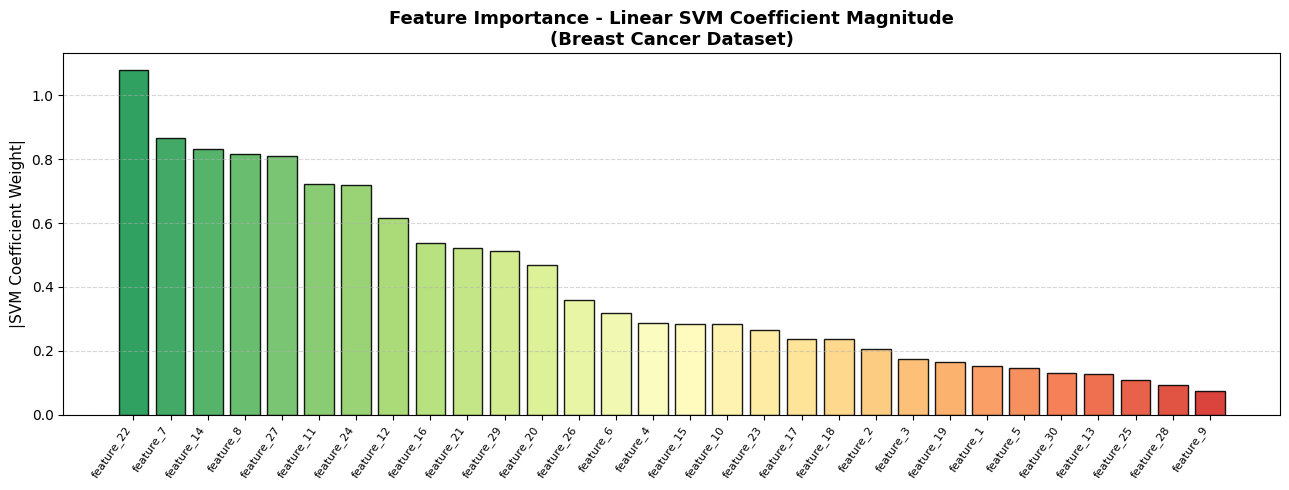


Top 5 most influential features:
  1. feature_22                           |w| = 1.0786
  2. feature_7                            |w| = 0.8681
  3. feature_14                           |w| = 0.8328
  4. feature_8                            |w| = 0.8161
  5. feature_27                           |w| = 0.8098


In [77]:
# Train a linear SVM on the full 30-feature cancer data
svm_lin_fi = SVC(kernel='linear', C=1, random_state=42)
svm_lin_fi.fit(X_train, y_train)

feature_names_cancer = X_cancer.columns.tolist()
weights = np.abs(svm_lin_fi.coef_[0])
sorted_idx = np.argsort(weights)[::-1]

# Bar chart
plt.figure(figsize=(13, 5))
bar_vals = weights[sorted_idx]
bar_lbls = [feature_names_cancer[i] for i in sorted_idx]
bar_cols  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(bar_vals)))

bars = plt.bar(bar_lbls, bar_vals, color=bar_cols, edgecolor='k', alpha=0.9)
plt.xticks(rotation=55, ha='right', fontsize=8)
plt.ylabel('|SVM Coefficient Weight|', fontsize=11)
plt.title('Feature Importance - Linear SVM Coefficient Magnitude\n(Breast Cancer Dataset)',
          fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nTop 5 most influential features:")
for rank, i in enumerate(sorted_idx[:5], 1):
    print(f"  {rank}. {feature_names_cancer[i]:35s}  |w| = {weights[i]:.4f}")


### Key Findings - Feature Importance

The magnitude of the linear SVM weight vector `|w_i|` indicates how strongly feature *i* influences
the classification decision:
- **High |w|** -> the feature strongly pushes samples towards one class.
- **Low |w|**  -> the feature contributes little discriminatory power.

Features from the **"worst"** measurements (largest cell dimensions in the tumour sample) tend to have
the highest weights, which is clinically meaningful - malignant tumours exhibit more extreme cellular
abnormalities.

---

## Summary Table

| Concept | What We Learned |
|---|---|
| **Kernel Comparison** | Linear is best when data is nearly linearly separable; RBF handles non-linear boundaries. All kernels achieved AUC > 0.99. |
| **PCA Biplot** | Loading vectors reveal which original features drive each PC, restoring some interpretability. |
| **Decision Boundary** | Visualising SVM boundaries shows the role of support vectors and the effect of kernel choice. |
| **Feature Importance** | `|w_i|` from a linear SVM reveals that worst-measurement features are the strongest predictors of malignancy. |

### Broader Takeaway
> **SVM** is a maximum-margin classifier ideal for high-dimensional problems where the margin
> between classes provides strong generalisation.
>
> **PCA** (unsupervised) and **LDA** (supervised) are complementary dimensionality reduction tools
> that serve different purposes - variance preservation vs. class separability.
>
> Combining SVM + PCA is a powerful pipeline: PCA reduces noise and redundancy, and SVM finds the
> optimal separating boundary in the compressed space.
